# VARM - Project 1

# a. Face detection
> Use one of these algorithms to implement face detection in images collected in real time by a camera (see [1,2] for documentation and [3,4] as examples of implementation).<br>
> [1] - https://docs.opencv.org/master/d6/d0f/group__dnn.html#ga33d1b39b53a891e98a654fdeabba22eb <br>
> [2] - https://github.com/opencv/opencv/wiki/Deep-Learning-in-OpenCV<br>
> [3] - https://docs.opencv.org/3.4/db/d28/tutorial_cascade_classifier.html<br>
> [4] - https://towardsdatascience.com/face-detection-models-which-to-use-and-why-d263e82c302c <br><br>

The code for real-time face detection with camera is on ```a_i.py```, ```a_ii.py```, ```a_ii.py``` and ```a_iv.py``` respectively.

## i. Haar Cascade Classifier
> OpenCV “CascadeClassifier” method is based on the algorithm of object detection using Haar feature-based cascade classifiers proposed by Paul Viola and Michael Jones in their paper, “Rapid Object Detection using a Boosted Cascade of Simple Features” in 2001.

The code for real-time face detection with camera is on ```a_i.py```

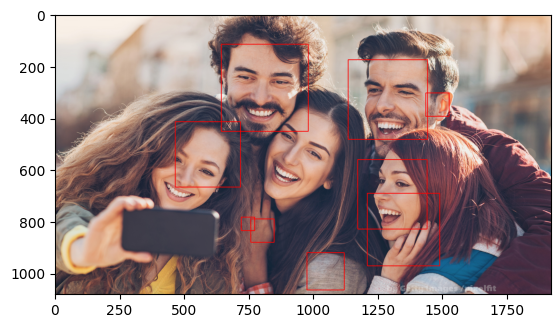

In [1]:
import cv2
import os
import matplotlib.pyplot as plt

# load image
img_path = os.path.join(os.getcwd(), 'formacao_a-importancia-dos-lacos-de-amizade-em-nossa-vidas.jpeg')
img = cv2.imread(img_path)

# initialize pre-trained classifier
classifier = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

faces = classifier.detectMultiScale(img)# result
# to draw faces on image
for result in faces:
    x, y, w, h = result
    x1, y1 = x + w, y + h
    cv2.rectangle(img, (x, y), (x1, y1), (0, 0, 255), 2)

# display the result
#cv2.imshow('img', img)
#cv2.waitKey()
#cv2.destroyAllWindows()

# convert from BGR to RGB to show on plt
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
plt.imshow(image)

## iii. dlib toobox
> Dlib is a toolkit containing machine learning algorithms and tools [5]. It has a set of methods to perform face and facial landmark detection, including up to 68 facial feature points estimation. The face detector uses the Histogram of Oriented Gradients (HOG) feature combined with a linear classifier.<br>
> [5] - http://dlib.net/

The code for real-time face detection with camera is on ```a_iii.py```

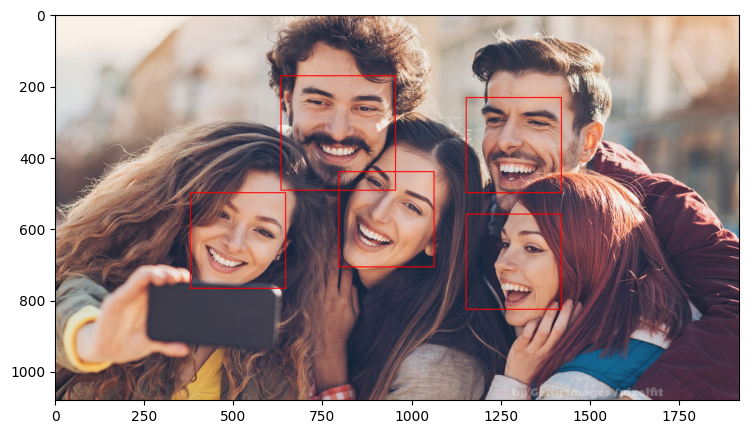

In [2]:
# !brew install cmake boost
# !pip install dlib
import dlib 
import cv2
detector = dlib.get_frontal_face_detector()
img = cv2.imread(img_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# The 1 in the second argument indicates that we should upsample the image 1 time. 
# This will make everything bigger and allow us to detect more faces.
faces = detector(gray, 1) # result
#to draw faces on image
for result in faces:
    x = result.left()
    y = result.top()
    x1 = result.right()
    y1 = result.bottom()
    cv2.rectangle(img, (x, y), (x1, y1), (0, 0, 255), 2)

# convert from BGR to RGB to show on plt
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
plt.figure(figsize=(10,5))
plt.imshow(image)

## iv. Mediapipe
> The MediaPipe Face Detector [6] task detects faces in an image or video. This task can locate faces and facial features within a frame. This task uses a machine learning (ML) model that works with single images or a continuous stream of images. The task outputs face locations, along with the following facial key points: left eye, right eye, nose tip, mouth, left eye tragion, and right eye tragion.<br>
> [6] - https://developers.google.com/mediapipe/solutions/vision/face_detector

The code for real-time face detection with camera is on ```a_iv.py```

# b. Face Recognition

## i. Face database: 
Perform the acquisition of a face database from the students in the class (7 face images for each student). This set will be used in this project as the training and test sets. It may also be used a face database available on the Internet.

Dataset source: https://www.kaggle.com/datasets/vasukipatel/face-recognition-dataset

100%|██████████| 31/31 [00:35<00:00,  1.16s/it]


(<matplotlib.image.AxesImage at 0x7fe3861869d0>, 'Virat Kohli')

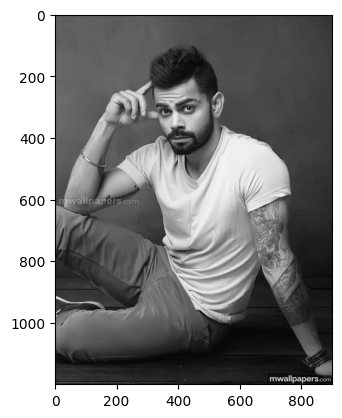

In [3]:
# !pip install tqdm
import os 
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

# Prepare the training set consisting of N faces, x1...xN, properly aligned
faces_path = os.path.join(os.getcwd(), 'faces', 'Original Images', 'Original Images')

X, Y = [], []
for img_name in tqdm(os.listdir(faces_path)):
    face_folder = os.path.join(faces_path, img_name)
    for img_pic in os.listdir(face_folder):
        img_path = os.path.join(faces_path, img_name, img_pic)
        #os.rename(img_path, img_path.replace("jpg", "jpeg")) #was throwing error with jpg

        # read image
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        X.append(img)
        Y.append(img_path.split('/')[-1].split('_')[0])

plt.imshow(X[0], cmap='gray'), Y[0]

# ii. Face normalization
Proceed with the normalization of the face images from the training set (rotation, scaling, selection) so that the faces comply with the format defined by MPEG-7 recommendation. That is, each face is represented by a monochrome image (256 levels) with 56 rows and 46 columns, with both eyes, right and left, perfectly aligned horizontally, and located in line 24, columns 16 and 31, respectively.

For eye detection, Haar Cascade classifier can also be used with proper XML classifiers files.

https://aanilkayy.medium.com/extract-eyes-in-face-i%CC%87mages-with-dlib-and-face-landmark-points-c45ef480c1



In [4]:
import cv2
import dlib
import numpy as np

# Load face and eye detectors
face_detector = dlib.get_frontal_face_detector()
eye_detector = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# Define desired image dimensions
IMG_HEIGHT, IMG_WIDTH = 56, 46
DESIRED_LEFT_EYE_X, DESIRED_RIGHT_EYE_X = 16, 31

def normalize_face(img):
    # Convert image to grayscale
    gray = img #cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Detect face
    detections = face_detector(gray, 1)
    if len(detections) != 1:
        raise ValueError('Image must contain exactly one face')
    face = detections[0]

    # Get face square coordinates
    x1, y1, x2, y2 = face.left(), face.top(), face.right(), face.bottom()

    # Crop and resize face square
    # By resizing the image before rotating, the distance between the eyes in the 
    # resized image can be used to calculate the angle of rotation required to align 
    # the eyes horizontally. This angle can then be used to rotate the original, un-resized 
    # image to achieve the desired eye alignment.
    # If the image was rotated first, then the distance between the eyes would change due to the rotation, which would make it difficult to accurately calculate the required angle of rotation to achieve the desired eye alignment.
    pad = 1
    face_square = gray[y1-pad:y2+pad, x1-pad:x2+pad] #cv2.resize(gray[y1:y2, x1:x2], (IMG_WIDTH, IMG_HEIGHT))
    #face_square = cv2.resize(gray[y1-pad:y2+pad, x1-pad:x2+pad], (IMG_WIDTH, IMG_HEIGHT))
    #plt.imshow(face_square, cmap='gray')
    
    # Detect eyes in the face square
    eyes = eye_detector.detectMultiScale(face_square)#, scaleFactor=5, minNeighbors=5)
    #print(eyes)
    if len(eyes) != 2:
        # return face_square
        return cv2.resize(face_square, (IMG_WIDTH, IMG_HEIGHT))
        #raise ValueError('Both eyes must be detected in the face image')

    # Get left and right eye squares
    left_eye, right_eye = sorted(eyes, key=lambda x: x[0])
    left_eye_x, left_eye_y, left_eye_w, left_eye_h = left_eye
    right_eye_x, right_eye_y, right_eye_w, right_eye_h = right_eye
    left_eye_square = face_square[left_eye_y:left_eye_y+left_eye_h, left_eye_x:left_eye_x+left_eye_w]
    right_eye_square = face_square[right_eye_y:right_eye_y+right_eye_h, right_eye_x:right_eye_x+right_eye_w]



    # Calculate the angle between the eyes
    eye_dx = right_eye_x + right_eye_w/2 - (left_eye_x + left_eye_w/2)
    eye_dy = right_eye_y + right_eye_h/2 - (left_eye_y + left_eye_h/2)
    angle = np.degrees(np.arctan2(eye_dy, eye_dx))

    # Calculate the desired coordinates of the left and right eye centers
    desired_left_eye_center = (DESIRED_LEFT_EYE_X, IMG_HEIGHT//2)
    desired_right_eye_center = (DESIRED_RIGHT_EYE_X, IMG_HEIGHT//2)
  
    # Calculate the scale factor to fit the face between the eyes and resize face
    #eyes_dist = np.sqrt(eye_dx**2 + eye_dy**2)
    scale = 1 #(desired_right_eye_center[0] - desired_left_eye_center[0]) / eyes_dist
    M = cv2.getRotationMatrix2D((left_eye_x + left_eye_w/2, left_eye_y + left_eye_h/2), angle, scale)
    face_norm = cv2.warpAffine(face_square, M, (face_square.shape[0], face_square.shape[1]))
    face_norm = cv2.resize(face_norm, (IMG_WIDTH, IMG_HEIGHT))
    #plt.imshow(face_norm, cmap='gray')
    # Return normalized face
    return face_norm


X_norm = []
for i, img in tqdm(enumerate(X[:5])):
    X_norm.append(normalize_face(img))


5it [00:01,  3.68it/s]


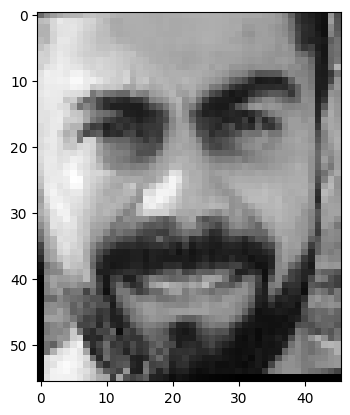

In [5]:
plt.imshow(X_norm[2], cmap='gray')

<h3>Load an already normalized dataset for Eigenfaces and Fisherfaces</h3>

(<matplotlib.image.AxesImage at 0x7fe26f316fa0>, 'Camila Cabello')

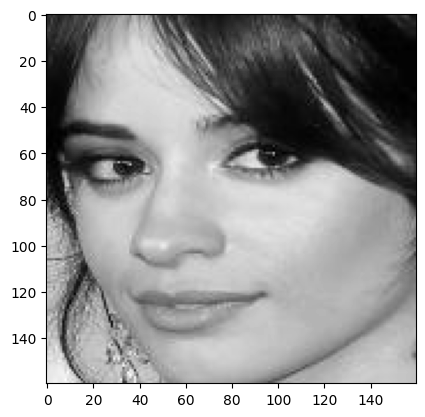

In [6]:

from sklearn.model_selection import train_test_split

# Prepare the training set consisting of N faces, x1...xN, properly aligned
faces_path = os.path.join(os.getcwd(), 'faces', 'Faces', 'Faces')

Xn, Yn = [], []
for img_name in os.listdir(faces_path):
    img_path = os.path.join(faces_path, img_name)
    #os.rename(img_path, img_path.replace("jpg", "jpeg")) #was throwing error with jpg

    # read image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    #img = cv2.resize(img, (56, 46))
    
    Xn.append(img)
    Yn.append(img_path.split('/')[-1].split('_')[0])

Xn, Yn = np.array(Xn), np.array(Yn)

Xtrain, Xtest, ytrain, ytest = train_test_split(Xn, Yn, test_size=0.3)

plt.imshow(Xtrain[0], cmap='gray'), ytrain[0]

## iii. Using EigenFaces
1. Compute the mean face vector μ (column vector with size of 2576x1) and the transformation matrix 𝑊𝑝𝑐𝑎 (with size of 2576×m), containing the first m eigenfaces (where m can be a number between 10 and 20). Use the procedures presented in the slides of the course. View the m+1 obtained vectors by interpreting them as face images (eigenface) and prove that they form an orthogonal basis.

Faces shape: (1793, 2576)
Mean Face shape: (2576, 1)
A element shape: (1793,)
A shape: (2576, 1793)
R shape: (1793, 1793)
eigvals shape: (1793,) eigvecs shape: (1793, 1793)
20
Top m indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
V shape: (1793, 20)
W shape: (2576, 20)
W_ shape: (2576, 20)
Projections shape: (20, 1793)


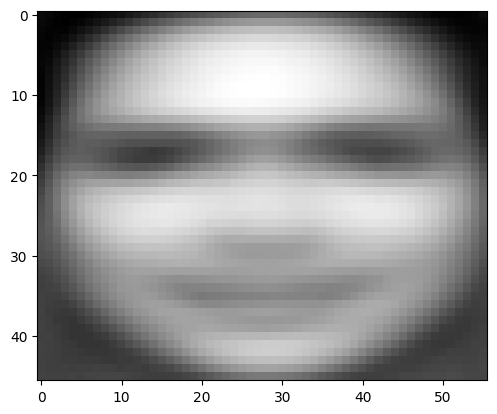

In [7]:
from sklearn.metrics import pairwise_distances
class EigenfacesModel():
    def __init__(self, m: int = 20) -> None:
        self.m = m
        self.faces = None
        self.mean_face = None
        self.A = None
        self.R = None
        self.V = None
        self.W = None # W cols form and orthonormal basis
        self.projections = None # y = np.dot(W.T, A)
    
    def fit(self, Xtrain, ytrain):

        # transform images into vectors
        faces = []
        for image in Xtrain:
            image = cv2.resize(image, (56, 46))
            faces.append(image.flatten())
        self.faces = np.array(faces)
        print("Faces shape:", self.faces.shape)
        #Faces shape: (2562, 2576)

        # mean face
        self.mean_face = np.mean(self.faces, axis=0)
        self.mean_face = self.mean_face.reshape(((self.mean_face.shape[0], 1)))
        print("Mean Face shape:", self.mean_face.shape) 
        #Mean Face shape: (2576, 1)

        # Compute matrix A containing the "AC components" of the faces from the training set
        self.A = self.faces.T - self.mean_face
        #self.A = self.A.T
        print("A element shape:", self.A[0].shape)
        #A element shape: (2576,)
        
        #self.A = self.A.T
        print("A shape:", self.A.shape)
        #A shape: (2562, 2576)        

        # Compute the eigenvectors and eigenvalues of matrix R = ATA (size of N×N)
        self.R = np.dot(self.A.T, self.A)
        print("R shape:", self.R.shape)
        #R shape: (2576, 2576)
        eigvals, eigvecs = np.linalg.eig(self.R)
        print("eigvals shape:", eigvals.shape, "eigvecs shape:", eigvecs.shape)

        # Select m (maximum of N-1) eigenvectors from R, associated to the highest eigenvalues 
        # and define matrix V (N×m), formed by the m eigenvectors of R
        if self.m==0: # good practice but more expensive
            m = min(eigvecs.shape[0], len(Xtrain) - 1) 
        else:
            m = self.m
        print(m)

        # get top-m eigenvalues indices
        top_m_indices = np.argsort(eigvals)[::-1][:m]
        print("Top m indices:", top_m_indices)
        # get top-m eigevectors (V)
        self.V = eigvecs[:, top_m_indices]
        print("V shape:", self.V.shape)
        #V shape: (2576, 20)

        # Compute the weights for each face
        self.W = np.dot(self.A, self.V)
        print("W shape:", self.W.shape)
        # W shape: (2562, 20) devia ser ()
        self.W_ = self.W/np.linalg.norm(self.W, axis=0)
        print("W_ shape:", self.W_.shape)

        # Compute the projections of each face onto the face subspace
        #self.projections = np.dot(self.W, self.V.T)
        self.projections = np.dot(self.W.T, self.A)
        #self.projections = np.dot(self.W.T, self.W)
        print("Projections shape:", self.projections.shape)

    def predict(self, test_img):

        # resize image
        test_img = cv2.resize(test_img, (56, 46))

        # center image
        centered_test_img = test_img.flatten() - self.mean_face.flatten() 
        print("centered_image shape:", centered_test_img.shape)
        print("V shape: ", self.V.shape)
        print("W shape: ", self.W.shape)

        # Project the test image onto the face subspace
        #test_projection = np.dot(centered_test_img.reshape(1, -1), self.V)
        #test_projection = np.dot(centered_test_img, self.W)
        test_projection = np.dot(self.W.T, centered_test_img)
        print("Test projection shape:", test_projection.shape)

        # Find the index of the closest matching face in the training set
        min_dist = np.inf
        min_index = -1
        # compute euclidean distances of test projection to each train projection
        for i in range(len(self.projections)):
            dist = np.linalg.norm(test_projection - self.projections[:, i])
            # update if a more similar projection is found
            if dist < min_dist:
                min_dist = dist
                min_index = i
              

        # Return the filename of the closest matching face
        return self.faces[min_index].reshape((46, 56)), min_index
    
    def get_error_faces_and_reconstructions(self, indices=[0, 5, 10]):
        
        # Selected already centered samples from A
        selected_faces = self.A[:, indices]
        print("Selected faces:", selected_faces.shape)
        #Selected faces: (2576, 3)
        print("V shape:", self.V.shape)
        #V shape: (2562, 20)

        # Project each centered face onto the face subspace
        selected_projections = np.dot(selected_faces, self.V[indices])
        print("Selected faces projections shape:", selected_projections.shape)
        # Selected faces projections shape: (2576, 20)
        #Resconstructions shape: (2576, 3)
        #Error faces shape: (2576, 3)

        # Reconstruct each face
        #reconstructions = np.dot(self.W, np.dot(self.W.T, self.V.T))
        reconstructions = np.dot(selected_projections, self.V[indices].T) #+ self.mean_face
        #reconstructions = np.dot(self.V.T, selected_faces) + self.mean_face
        #reconstructions = np.dot(self.W.T, selected_faces) + self.mean_face
        print("Resconstructions shape:", reconstructions.shape)
        # Compute the error face for each reconstructed face
        error_faces = selected_faces - reconstructions - self.mean_face
        print("Error faces shape:", error_faces.shape)

        # Verify that the error face is orthogonal to the face subspace
        orthogonality = np.dot(error_faces, self.V[indices])
        print(orthogonality)
        # Verify that the error face is orthogonal to the face subspace
        #orthogonality = np.dot(error_faces.reshape(2576, -1).T, eigenfaces.V)
        print("Orthogonality check:", np.allclose(orthogonality, np.zeros((orthogonality.shape))))

        return error_faces, reconstructions

    def evaluate(self, ytrue, ypred):
        pass

eigenfaces = EigenfacesModel(m = 20) #len(Xn)-1)

eigenfaces.fit(Xtrain, ytrain) # #eigenfaces.fit(X_norm, Yn)

plt.imshow(eigenfaces.mean_face.reshape((46,56)), cmap='gray')


## Predict face using Nearest-Neighbour
i.e., the nearest projection 

centered_image shape: (2576,)
V shape:  (1793, 20)
W shape:  (2576, 20)
Test projection shape: (20,)


Text(0.5, 1.0, 'Predicted face - Tom Cruise')

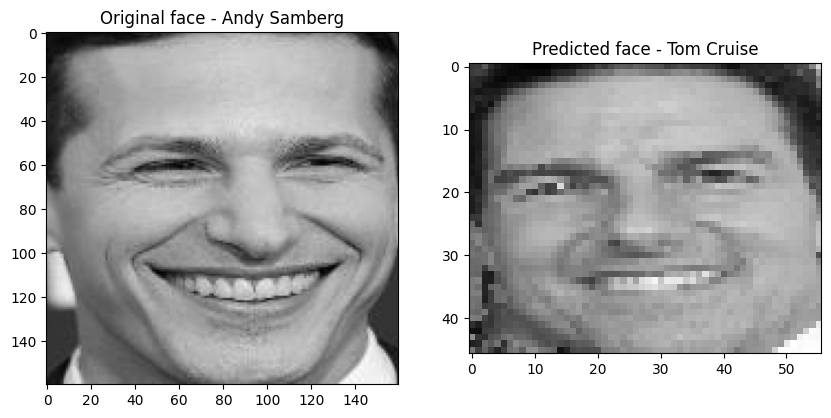

In [18]:
ex = 66
pred_face, pred_idx = eigenfaces.predict(Xtest[ex])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(Xtest[ex], cmap='gray')
axs[0].set_title(f'Original face - {ytest[ex]}')
axs[1].imshow(pred_face, cmap='gray')
axs[1].set_title(f'Predicted face - {ytrain[pred_idx]}')

## Reconstructed faces and error faces
2. Preform the projection of some of the training set faces on the face subspace and observe their reconstructions. Compute (and view) the error face (difference between the original face and its reconstruction). Show that the error face is orthogonal to the face subspace.

Selected faces: (2576, 3)
V shape: (1793, 20)
Selected faces projections shape: (2576, 20)
Resconstructions shape: (2576, 3)
Error faces shape: (2576, 3)
[[-3.90173207 -5.20808201  6.55331112 ... -1.46828899 -0.61698626
   2.48544124]
 [-3.64435682 -4.47270942  6.33146455 ... -1.69735296 -0.35653594
   2.16680315]
 [-2.80720269 -2.7564205   5.19331037 ... -1.84007927  0.12026425
   1.39332217]
 ...
 [-4.89762172 -0.55020778  3.68987478 ... -0.99796124  3.81950597
   0.20920145]
 [-5.04016761 -0.43740721  4.06830144 ... -1.28584044  3.97072991
   0.17867847]
 [ 0.86981069  3.2179709   1.7193281  ... -2.94334715  0.96018688
  -1.21968139]]
Orthogonality check: False


Text(0.5, 1.0, 'Reconstructed face 3')

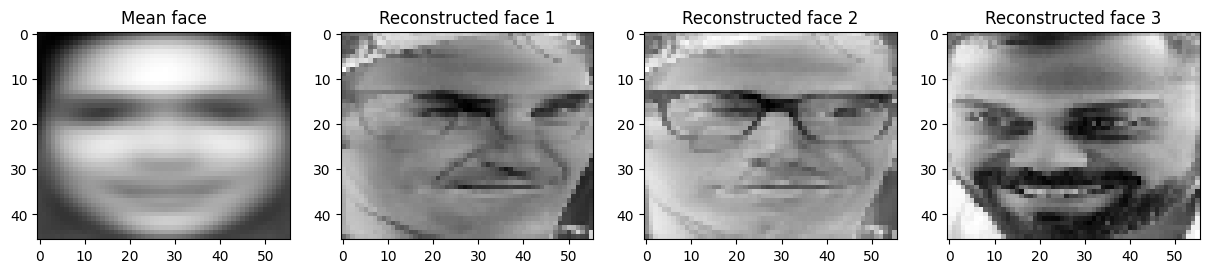

In [9]:
error_faces, reconstructions = eigenfaces.get_error_faces_and_reconstructions([22, 3, 7])

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(eigenfaces.mean_face.reshape(46,56), cmap='gray')
axs[0].set_title('Mean face')
axs[1].imshow(reconstructions[:, 0].reshape((46,56)).real, cmap='gray')
axs[1].set_title('Reconstructed face 1')
axs[2].imshow(reconstructions[:, 1].reshape((46,56)).real, cmap='gray')
axs[2].set_title('Reconstructed face 2')
axs[3].imshow(reconstructions[:, 2].reshape((46,56)).real, cmap='gray')
axs[3].set_title('Reconstructed face 3')


Text(0.5, 1.0, 'Error face 3')

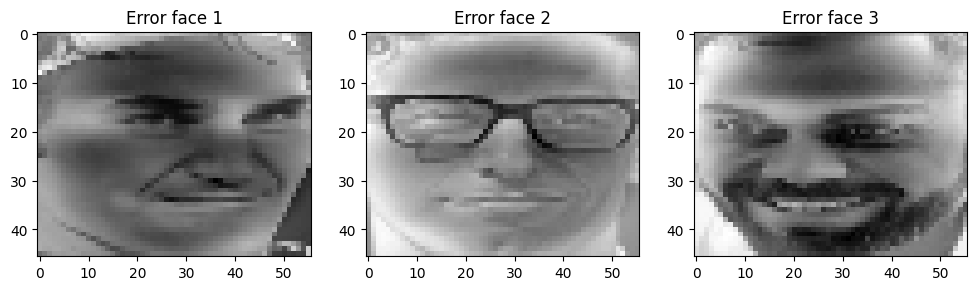

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].imshow(error_faces[:,0].reshape((46,56)).real, cmap='gray')
axs[0].set_title('Error face 1')
axs[1].imshow(error_faces[:,1].reshape((46,56)).real, cmap='gray')
axs[1].set_title('Error face 2')
axs[2].imshow(error_faces[:,2].reshape((46,56)).real, cmap='gray')
axs[2].set_title('Error face 3')

# Fisherfaces

In [11]:
class FisherfacesModel():
    def __init__(self, m: int = 20) -> None:
        self.m = m
        self.faces = None
        self.mean_face = None
        self.A = None
        self.R = None
        self.Wpca = None
        self.Wfisher = None
    
    def fit(self, Xtrain, ytrain):
        # transform images into vectors
        faces = []
        for image in Xtrain:
            image = cv2.resize(image, (56, 46))
            faces.append(image.flatten())
        self.faces = np.array(faces)
        print("Faces shape:", self.faces.shape)

        print("EigenfacesModel")
        pca = EigenfacesModel(self.m)
        pca.fit(Xtrain, ytrain)

        # compute mean face
        self.mean_face = pca.mean_face #np.mean(self.faces, axis=0)
        #self.mean_face = self.mean_face.reshape(((self.mean_face.shape[0], 1)))
        print("Mean Face shape:", self.mean_face.shape)

        # subtract mean face from each image
        self.A = pca.A #self.faces.T - self.mean_face
        print("A shape:", self.A.shape)

        
        labels_names = np.unique(ytrain)
        labels = [i for i in range(len(labels_names))]
        
        num_classes = len(labels)
        num_features = 46*56
        num_images = len(Xtrain)

        # Compute the Sb and Sw matrices
        Sb = np.zeros((num_features, num_features))
        Sw = np.zeros((num_features, num_features))
        for i,label in enumerate(labels_names):
    
            class_faces = self.faces[ytrain==label]
            class_mean = np.mean(class_faces, axis=0)
            #print("class_faces:", class_faces.shape)
            #print("class_mean:", class_mean.shape)
            
            class_diff = class_mean - self.mean_face
            #print("class_diff:", class_diff.shape)
            Sb += np.dot(class_diff.T, class_diff)

            class_centered = class_faces - class_mean
            #print("class_centered:", class_centered.shape)
            Sw += np.dot(class_centered.T, class_centered)
           

        # Compute PCA
        self.Wpca = pca.W
        self.Vpca = pca.V

        # Compute Sb and Sw in the PCA subspace
        Sb = np.dot(np.dot(self.Wpca.T, Sb), self.Wpca)
        Sw = np.dot(np.dot(self.Wpca.T, Sw), self.Wpca)
        #Sb = np.dot(np.dot(self.Vpca.T, Sb), self.Vpca)
        #Sw = np.dot(np.dot(self.Vpca.T, Sw), self.Vpca)
        
        # Determine the c-1 “larger eigenvectors” from the matrix Sw-1 Sb (mxm)
        # Compute the Fisherfaces basis
        inv_Sw_Sb = np.dot(np.linalg.inv(Sw), Sb)
        eigenvalues, eigenvectors = np.linalg.eig(inv_Sw_Sb)
        sorted_indices = np.argsort(eigenvalues.real)[::-1]
        #top_m_indices = sorted_indices[:m]
        eigenvalues = eigenvalues[sorted_indices]
        eigenvectors = eigenvectors[:, sorted_indices]
        self.Wfisher = np.dot(self.Wpca, eigenvectors[:, :num_classes - 1])
        # train projections
        self.projections = np.dot(self.Wfisher.T, self.A)
        #self.projections = np.dot(np.dot(self.Wfisher.T, self.Wpca), self.A)
        print("projections shape:", self.projections.shape)


    def predict(self, test_img):

        # resize image
        test_img = cv2.resize(test_img, (56, 46))

        # center image
        centered_test_img = test_img.flatten() - self.mean_face.flatten() 
        print("centered_image shape:", centered_test_img.shape)
        print("Wfisher shape: ", self.Wfisher.shape)

        # Project the test image onto the face subspace
        #test_projection = np.dot(centered_test_img.reshape(1, -1), self.V)
        #test_projection = np.dot(centered_test_img, self.W)
        test_projection = np.dot(self.Wfisher.T, centered_test_img)
        print("Test projection shape:", test_projection.shape)

        # Find the index of the closest matching face in the training set
        min_dist = np.inf
        min_index = -1
        # compute euclidean distances of test projection to each train projection
        for i in range(len(self.projections)):
            dist = np.linalg.norm(test_projection - self.projections[:, i])
            # update if a more similar projection is found
            if dist < min_dist:
                min_dist = dist
                min_index = i
              

        # Return the filename of the closest matching face
        return self.faces[min_index].reshape((46, 56)), min_index
    
    def get_error_faces_and_reconstructions(self, indices=[0, 5, 10]):

        
        # Selected already centered samples from A
        selected_faces = self.A[:, indices]
        print("Selected faces:", selected_faces.shape)
        #Selected faces: (2576, 3)
        print("V shape:", self.Wfisher.shape)
        #V shape: (2562, 20)

        # Project each centered face onto the face subspace
        #selected_projections =np.dot(np.dot(selected_faces, self.Wfisher[indices]), self.Vpca)
        #selected_projections = np.dot(selected_faces, self.Wfisher[indices])
        selected_projections = np.dot(self.Wfisher[indices].T, selected_faces.T)
        print("Selected faces projections shape:", selected_projections.shape)
        # Selected faces projections shape: (2576, 20)
        #Resconstructions shape: (2576, 3)
        #Error faces shape: (2576, 3)

        # Reconstruct each face
        reconstructions = np.dot(selected_projections.T, self.Wfisher[indices].T) #+ self.mean_face
        #reconstructions = np.dot(self.V.T, selected_faces) + self.mean_face
        #reconstructions = np.dot(self.W.T, selected_faces) + self.mean_face
        print("Resconstructions shape:", reconstructions.shape)
        # Compute the error face for each reconstructed face
        error_faces = selected_faces - reconstructions
        print("Error faces shape:", error_faces.shape)
        return error_faces, reconstructions
    

    def evaluate(self, ytrue, ypred):
        pass



Faces shape: (2562, 2576)
EigenfacesModel
Faces shape: (2562, 2576)
Mean Face shape: (2576, 1)
A element shape: (2562,)
A shape: (2576, 2562)
R shape: (2562, 2562)
eigvals shape: (2562,) eigvecs shape: (2562, 2562)
20
Top m indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
V shape: (2562, 20)
W shape: (2576, 20)
W_ shape: (2576, 20)
Projections shape: (20, 2562)
Mean Face shape: (2576, 1)
A shape: (2576, 2562)
projections shape: (20, 2562)


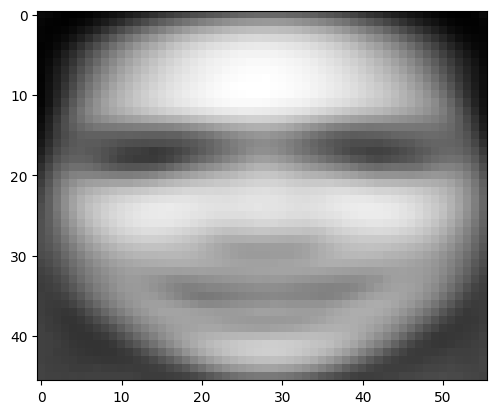

In [12]:
fisherfaces = FisherfacesModel(m = 20) 

fisherfaces.fit(Xn, Yn) 

plt.imshow(fisherfaces.mean_face.reshape((46,56)), cmap='gray')

## Predict face using Nearest-Neighbour
i.e., the nearest projection 

centered_image shape: (2576,)
Wfisher shape:  (2576, 20)
Test projection shape: (20,)


Text(0.5, 1.0, 'Predicted face - Virat Kohli')

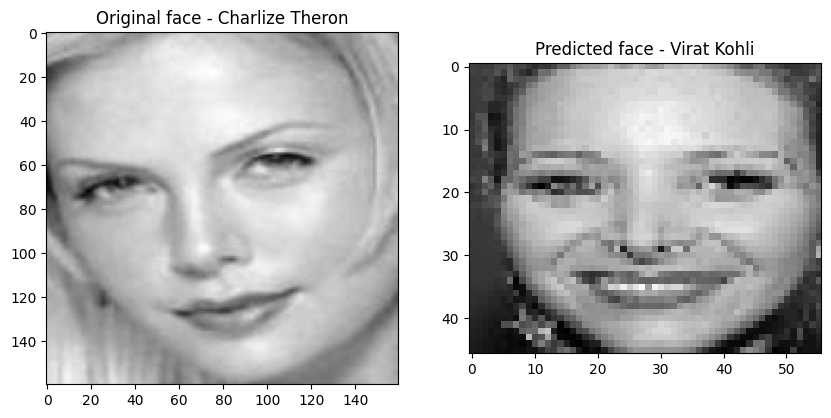

In [13]:
ex = 88
pred_face, pred_idx = fisherfaces.predict(Xtest[ex])

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(Xtest[ex], cmap='gray')
axs[0].set_title(f'Original face - {ytest[ex]}')
axs[1].imshow(pred_face, cmap='gray')
axs[1].set_title(f'Predicted face - {ytrain[pred_idx]}')

## Reconstructed faces and error faces
2. Preform the projection of some of the training set faces on the face subspace and observe their reconstructions. Compute (and view) the error face (difference between the original face and its reconstruction). Show that the error face is orthogonal to the face subspace.

Selected faces: (2576, 3)
V shape: (2576, 20)
Selected faces projections shape: (20, 2576)
Resconstructions shape: (2576, 3)
Error faces shape: (2576, 3)


Text(0.5, 1.0, 'Reconstructed face 3')

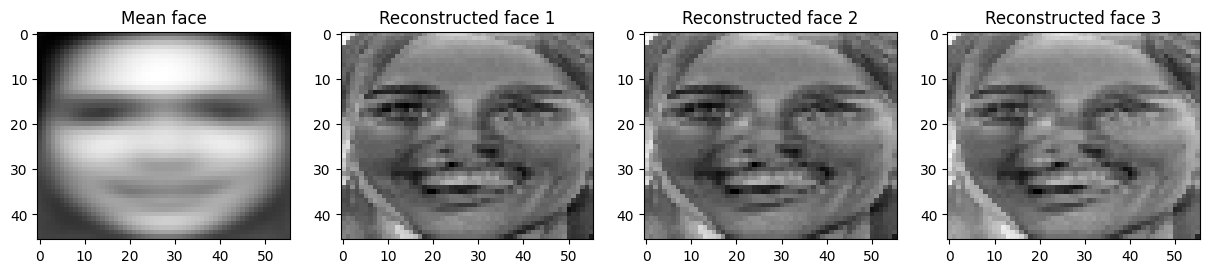

In [14]:
error_faces, reconstructions = fisherfaces.get_error_faces_and_reconstructions()

fig, axs = plt.subplots(1, 4, figsize=(15, 5))
axs[0].imshow(fisherfaces.mean_face.reshape(46,56), cmap='gray')
axs[0].set_title('Mean face')
axs[1].imshow(reconstructions[:, 0].reshape((46,56)).real, cmap='gray')
axs[1].set_title('Reconstructed face 1')
axs[2].imshow(reconstructions[:, 1].reshape((46,56)).real, cmap='gray')
axs[2].set_title('Reconstructed face 2')
axs[3].imshow(reconstructions[:, 2].reshape((46,56)).real, cmap='gray')
axs[3].set_title('Reconstructed face 3')

Text(0.5, 1.0, 'Error face 3')

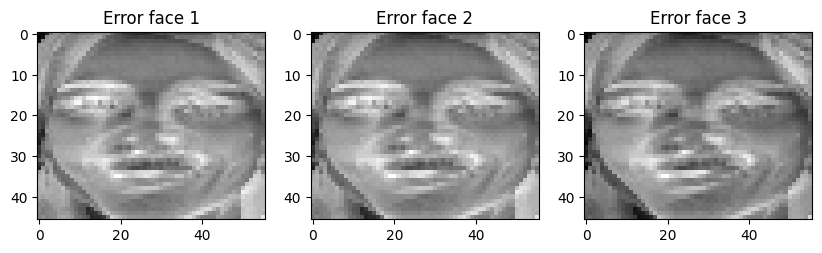

In [15]:
fig, axs = plt.subplots(1, 3, figsize=(10, 5))
axs[0].imshow(error_faces[:,0].reshape((46,56)).real, cmap='gray')
axs[0].set_title('Error face 1')
axs[1].imshow(error_faces[:,1].reshape((46,56)).real, cmap='gray')
axs[1].set_title('Error face 2')
axs[2].imshow(error_faces[:,2].reshape((46,56)).real, cmap='gray')
axs[2].set_title('Error face 3')

# c. Combine real and virtual objects.
## i. Virtual object normalization

Based on the alignment of section b.ii, normalize the virtual object that is intended to be superimposed on the identified face, for example, a hat, glasses, or other object of your choice. Use different objects for different faces/persons.


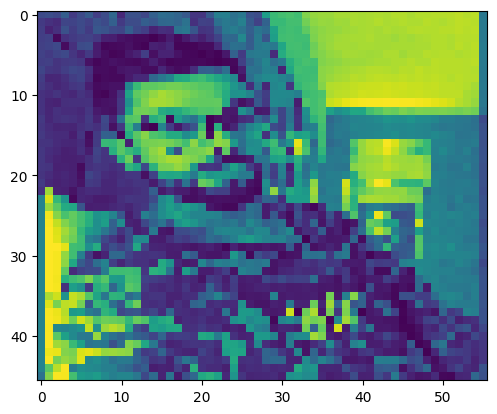

In [16]:

def superimpose_hat(image, x, y, w, h):
    
    hat_img = cv2.imread('./hat.png')
    plt.imshow(hat_img)

    hat_h, hat_w, _ = hat_img.shape
    scale_factor = 1.5  # Adjust the scale factor as needed
    hat_width = int(w * scale_factor)
    hat_height = int(hat_width * (hat_h / hat_w))
    hat_img = cv2.resize(hat_img, (hat_width, hat_height))

    hat_img = cv2.resize(hat_img, (hat_width, hat_height))

    # Calculate the new y-coordinate for placing the hat on the top of the face
    new_y = y - int(0.50 * h)  # Adjust the percentage as needed
    new_x = x - int(0.25 * w)  # Adjust the percentage as needed

    # Iterate over the pixels of the hat image and copy them to the face image
    for i in range(hat_height):
        for j in range(hat_width):
            for k in range(3):
                if hat_img[i][j][k] < 235:
                    image[new_y + i][new_x + j][k] = hat_img[i][j][k]

    return image



# initialize pre-trained classifier
classifier = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

# Detect faces in the grayscale image
image = cv2.resize(X[45], (56,46))
faces = classifier.detectMultiScale(image, scaleFactor=1.3, minNeighbors=5)

for (x, y, w, h) in faces:
    # limit face square
    face_square = cv2.resize(gray[y:y+h, x:x+w], (46, 56))

    # auperimpose hat
    image = superimpose_hat(image, x, y, w, h)

# Display the color frame with detected faces
plt.imshow(image)



## ii. Adding with mask
Add to the image, using a mask.